In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
autos=pd.read_csv('./Datasets TP/autos.csv', encoding='latin1',sep=';')
autos

,marca_A,modelo_A,segmento_A,carroceria_A,combustible_A,transmision_A,puertas_A,potencia_cv_A,cilindrada_cc_A,consumo_l100_A,...,consumo_l100_N,precio_compra_N,condicion_compra_N,financiacion_N,fecha_compra_N,satisfaccion_general_N,satisfaccion_consumo_N,satisfaccion_confort_N,satisfaccion_seguridad_N,respondent_id
0,MarcaC,ModeloE,D,Sedan,Nafta,Manual,5,134,1995,7.25,...,9.26,53180,0KM,Plan,2018-06,6,3,4,3,R1095
1,MarcaF,ModeloC,Utilitario,SUV,Diesel,Automática,4,89,1692,8.86,...,8.60,37294,0KM,Contado,2021-10,3,6,5,5,R1015
2,MarcaC,ModeloH,SUV-B,Sedan,Nafta,Manual,5,131,1720,8.74,...,6.93,27517,0KM,Contado,2018-09,5,6,5,6,R1030
3,MarcaC,ModeloN,B,Hatch,Diesel,Automática,4,88,1289,8.13,...,6.90,42811,Usado,Plan,2023-01,4,4,6,6,R1158
4,MarcaB,ModeloN,C,Pick-up,Nafta,Automática,5,119,1364,9.04,...,13.81,55413,Usado,Contado,2024-10,4,6,2,3,R1128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,MarcaG,ModeloN,C,Sedan,Nafta,Automática,4,102,1756,10.27,...,10.20,165350,0KM,Préstamo,2023-03,3,5,3,3,R1106
196,MarcaG,ModeloL,C,Sedan,Nafta,Manual,5,114,1393,10.51,...,7.02,63178,0KM,Préstamo,2023-01,4,5,6,5,R1014
197,MarcaB,ModeloI,SUV-C,Sedan,Híbrido,Automática,4,128,2523,8.79,...,10.65,143010,0KM,Contado,2019-04,6,3,5,6,R1092
198,MarcaF,ModeloL,D,Sedan,Nafta,Automática,4,235,2742,10.48,...,13.94,77554,Usado,Préstamo,2019-05,4,4,4,3,R1179


In [3]:
autos.isnull().sum()

marca_A                     0
modelo_A                    0
segmento_A                  0
carroceria_A                0
combustible_A               0
transmision_A               0
puertas_A                   0
potencia_cv_A               0
cilindrada_cc_A             0
consumo_l100_A              0
anio_compra_A               0
kilometraje_al_cambio_A     0
condicion_compra_A          0
financiacion_A              0
satisfaccion_general_A      0
satisfaccion_consumo_A      0
satisfaccion_confort_A      0
satisfaccion_seguridad_A    0
marca_N                     0
modelo_N                    0
segmento_N                  0
carroceria_N                0
combustible_N               0
transmision_N               0
puertas_N                   0
potencia_cv_N               0
cilindrada_cc_N             0
consumo_l100_N              0
precio_compra_N             0
condicion_compra_N          0
financiacion_N              0
fecha_compra_N              0
satisfaccion_general_N      0
satisfacci

In [4]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   marca_A                   200 non-null    object 
 1   modelo_A                  200 non-null    object 
 2   segmento_A                200 non-null    object 
 3   carroceria_A              200 non-null    object 
 4   combustible_A             200 non-null    object 
 5   transmision_A             200 non-null    object 
 6   puertas_A                 200 non-null    int64  
 7   potencia_cv_A             200 non-null    int64  
 8   cilindrada_cc_A           200 non-null    int64  
 9   consumo_l100_A            200 non-null    float64
 10  anio_compra_A             200 non-null    int64  
 11  kilometraje_al_cambio_A   200 non-null    int64  
 12  condicion_compra_A        200 non-null    object 
 13  financiacion_A            200 non-null    object 
 14  satisfacci

In [5]:
encuestados=pd.read_excel('./Datasets TP/encuestados.xlsx')
encuestados

,respondent_id,edad,sexo,tamanio_hogar,menores_en_hogar,ingreso_hogar,region,uso_principal_auto,km_promedio_mensual,motivo_principal_cambio,...,intencion_eco,restricciones_transito,estacionamiento_propio,uso_rutas_pct,delta_potencia,delta_cilindrada,delta_consumo,antiguedad_A_al_cambio,delta_puertas,delta_segmento_num
0,R1095,25,M,5,2,500k-1M,Centro,Familiar,1793,Tamaño/familia,...,baja,No,No,55,-71,-347,2.00,9,-1,-1
1,R1015,34,M,4,2,<500k,CABA/AMBA,Mixto,723,Tamaño/familia,...,baja,No,No,47,2,324,-0.27,16,1,0
2,R1030,33,F,4,2,1M-2M,Cuyo,Familiar,1256,Confort,...,baja,No,No,42,-74,-307,-1.81,10,0,-2
3,R1158,28,F,2,0,1M-2M,CABA/AMBA,Trabajo,1294,Estado/mantenimiento,...,baja,No,No,10,-26,222,-1.22,6,1,0
4,R1128,40,F,4,2,500k-1M,NOA,Ocio,1554,Seguridad,...,baja,No,No,29,-29,46,4.77,20,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,R1106,58,F,4,0,2M-4M,NOA,Familiar,699,TecnologÃ­a,...,baja,No,No,38,58,624,-0.07,9,1,1
196,R1014,22,M,1,0,<500k,Exterior,Mixto,958,Gasto/consumo,...,media,No,No,78,1,516,-3.49,8,0,0
197,R1092,32,F,4,1,2M-4M,NOA,Ocio,748,Gasto/consumo,...,alta,No,Si,14,21,-780,1.86,2,1,0
198,R1179,67,F,1,0,2M-4M,Centro,Familiar,1475,Trabajo,...,baja,No,No,55,-137,-1512,3.46,8,0,-1


In [6]:
encuestados.isnull().sum()

respondent_id                         0
edad                                  0
sexo                                  0
tamanio_hogar                         0
menores_en_hogar                      0
ingreso_hogar                         0
region                                0
uso_principal_auto                    0
km_promedio_mensual                   0
motivo_principal_cambio               0
criterios_importancia_precio          0
criterios_importancia_consumo         0
criterios_importancia_seguridad       0
criterios_importancia_confort         0
criterios_importancia_tecnologia      0
criterios_importancia_imagen          0
criterios_importancia_posventa        0
criterios_importancia_financiacion    0
fuente_concesionario                  0
fuente_webs_foros                     0
fuente_familia_amigos                 0
fuente_redes_sociales                 0
fuente_influencers                    0
fuente_prueba_manejo                  0
test_drive                            0


In [7]:
union=pd.merge(right=autos,left=encuestados,on='respondent_id',how='inner')
union

,respondent_id,edad,sexo,tamanio_hogar,menores_en_hogar,ingreso_hogar,region,uso_principal_auto,km_promedio_mensual,motivo_principal_cambio,...,cilindrada_cc_N,consumo_l100_N,precio_compra_N,condicion_compra_N,financiacion_N,fecha_compra_N,satisfaccion_general_N,satisfaccion_consumo_N,satisfaccion_confort_N,satisfaccion_seguridad_N
0,R1095,25,M,5,2,500k-1M,Centro,Familiar,1793,Tamaño/familia,...,1648,9.26,53180,0KM,Plan,2018-06,6,3,4,3
1,R1015,34,M,4,2,<500k,CABA/AMBA,Mixto,723,Tamaño/familia,...,2016,8.60,37294,0KM,Contado,2021-10,3,6,5,5
2,R1030,33,F,4,2,1M-2M,Cuyo,Familiar,1256,Confort,...,1413,6.93,27517,0KM,Contado,2018-09,5,6,5,6
3,R1158,28,F,2,0,1M-2M,CABA/AMBA,Trabajo,1294,Estado/mantenimiento,...,1511,6.90,42811,Usado,Plan,2023-01,4,4,6,6
4,R1128,40,F,4,2,500k-1M,NOA,Ocio,1554,Seguridad,...,1410,13.81,55413,Usado,Contado,2024-10,4,6,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,R1106,58,F,4,0,2M-4M,NOA,Familiar,699,TecnologÃ­a,...,2380,10.20,165350,0KM,Préstamo,2023-03,3,5,3,3
196,R1014,22,M,1,0,<500k,Exterior,Mixto,958,Gasto/consumo,...,1909,7.02,63178,0KM,Préstamo,2023-01,4,5,6,5
197,R1092,32,F,4,1,2M-4M,NOA,Ocio,748,Gasto/consumo,...,1743,10.65,143010,0KM,Contado,2019-04,6,3,5,6
198,R1179,67,F,1,0,2M-4M,Centro,Familiar,1475,Trabajo,...,1230,13.94,77554,Usado,Préstamo,2019-05,4,4,4,3


### Ejercicio 2

In [8]:
encuestados['ingreso_hogar'].value_counts()

ingreso_hogar
<500k      60
500k-1M    53
1M-2M      48
2M-4M      27
>4M        12
Name: count, dtype: int64

In [9]:
encuestados['menores_en_hogar'].value_counts()

menores_en_hogar
0    103
1     51
2     32
3     14
Name: count, dtype: int64

In [10]:
encuestados['region'].value_counts()

region
CABA/AMBA    63
Centro       43
Cuyo         23
NOA          23
NEA          23
Exterior     18
Patagonia     7
Name: count, dtype: int64

In [11]:
autos['consumo_l100_A']=autos['consumo_l100_A'].astype(float)

In [12]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   marca_A                   200 non-null    object 
 1   modelo_A                  200 non-null    object 
 2   segmento_A                200 non-null    object 
 3   carroceria_A              200 non-null    object 
 4   combustible_A             200 non-null    object 
 5   transmision_A             200 non-null    object 
 6   puertas_A                 200 non-null    int64  
 7   potencia_cv_A             200 non-null    int64  
 8   cilindrada_cc_A           200 non-null    int64  
 9   consumo_l100_A            200 non-null    float64
 10  anio_compra_A             200 non-null    int64  
 11  kilometraje_al_cambio_A   200 non-null    int64  
 12  condicion_compra_A        200 non-null    object 
 13  financiacion_A            200 non-null    object 
 14  satisfacci

In [13]:
autos['consumo_l100_A']

0       7.25
1       8.86
2       8.74
3       8.13
4       9.04
       ...  
195    10.27
196    10.51
197     8.79
198    10.48
199     8.26
Name: consumo_l100_A, Length: 200, dtype: float64

In [14]:
min=autos['consumo_l100_A'].min()
max=autos['consumo_l100_A'].max()
print(f'Consumo minimo cada 100km: {min} \nConsumo maximo cada 100km: {max}')

Consumo minimo cada 100km: 4.42 
Consumo maximo cada 100km: 16.29


* a) ingreso_hogar: 
  * Representa el ingreso mensual del hogar, suponemos que en pesos argentinos. 
  * Es de tipo cuantitativa continua. 
  * Su rango de valores va desde <500k hasta >4M, con rangos intermedios de 500k-1M, 1M-2M,2M-4M. 
  * Tipo de escala: de intervalo

* b) menores_en_hogar: 
  * Representa la cantidad de menores viviendo en el hogar. 
  * Es de tipo cuantitativa discreta. 
  * Su rango de valores va desde 0,1,2 y 3. 
  * Tipo de escala: de razon
  

* c) region: 
  * Representa las regiones del pais. 
  * Es de tipo cualitativo. 
  * Sus valores posibles son: CABA/AMBA, Centro, Cuyo, NOA, NEA, Exterior, Patagonia. 
  * Tipo de escala: nominal.
  

* d) consumo_l100_A: 
  * Representa el consumo de nafta de cada auto cada 100 kilometros del vehiculo anterior. 
  * Es de tipo cuantitativa continua. 
  * Sus posible valores van de 4.42 a 16.29 km/h. 
  * Tipo de escala: de razon.

### Ejercicio 3

In [16]:
encuestados['ingreso_hogar'].value_counts(normalize=True)*100

ingreso_hogar
<500k      30.0
500k-1M    26.5
1M-2M      24.0
2M-4M      13.5
>4M         6.0
Name: proportion, dtype: float64

Al observar la distribucion la mayoria de ingresos de hogar en 2024 no superaba el millon de pesos

In [49]:
encuestados['menores_en_hogar'].value_counts(normalize=True).round(3)*100

menores_en_hogar
0    51.5
1    25.5
2    16.0
3     7.0
Name: proportion, dtype: float64

Mas de la mitad de los encuestados no tienen hijos, y solo el 23% tiene mas de uno.

### Ejercicio 4

In [18]:
encuestados['motivo_principal_cambio'].value_counts()

motivo_principal_cambio
Seguridad               39
Gasto/consumo           37
Tamaño/familia          28
Confort                 27
Estado/mantenimiento    24
Otro                    16
Estética                14
TecnologÃ­a             10
Trabajo                  5
Name: count, dtype: int64

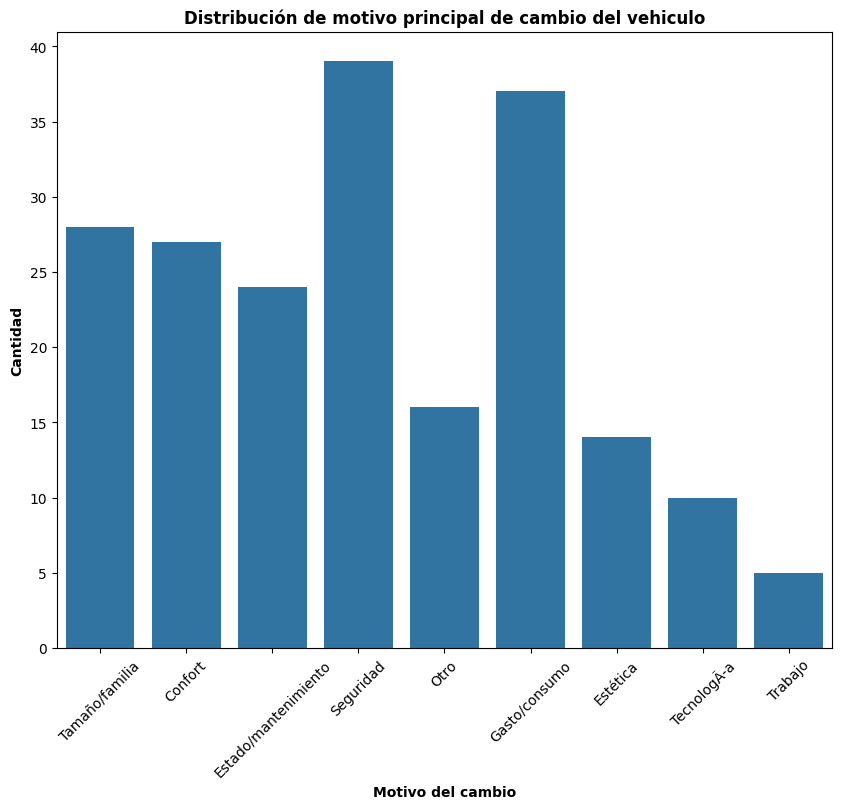

In [19]:
plt.figure(figsize=(10, 8))
sns.countplot(data=encuestados,x='motivo_principal_cambio')
plt.title('Distribución de motivo principal de cambio del vehiculo', fontweight='bold')
plt.xlabel('Motivo del cambio', fontweight='bold')
plt.ylabel('Cantidad', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [20]:
encuestados['motivo_principal_cambio'].value_counts()/len(encuestados)*100

motivo_principal_cambio
Seguridad               19.5
Gasto/consumo           18.5
Tamaño/familia          14.0
Confort                 13.5
Estado/mantenimiento    12.0
Otro                     8.0
Estética                 7.0
TecnologÃ­a              5.0
Trabajo                  2.5
Name: count, dtype: float64

El 5% de los motivos de cambios se realizaron por cuestion tecnologica

### Ejercicio 5

In [21]:
cuyo=union[(union['region']=='Cuyo')&(encuestados['ingreso_hogar']=='2M-4M')]
cuyo

,respondent_id,edad,sexo,tamanio_hogar,menores_en_hogar,ingreso_hogar,region,uso_principal_auto,km_promedio_mensual,motivo_principal_cambio,...,cilindrada_cc_N,consumo_l100_N,precio_compra_N,condicion_compra_N,financiacion_N,fecha_compra_N,satisfaccion_general_N,satisfaccion_consumo_N,satisfaccion_confort_N,satisfaccion_seguridad_N
41,R1197,41,M,4,0,2M-4M,Cuyo,Familiar,823,Tamaño/familia,...,2408,10.30,158670,Usado,Contado,2020-05,5,6,5,5
44,R1122,54,F,2,0,2M-4M,Cuyo,Trabajo,113,Estética,...,1801,8.51,61553,Usado,Contado,2018-04,6,3,3,5
60,R1169,32,F,2,0,2M-4M,Cuyo,Familiar,1857,Tamaño/familia,...,2032,9.68,130270,0KM,Préstamo,2020-02,3,7,5,4
112,R1198,40,M,2,0,2M-4M,Cuyo,Familiar,1359,Seguridad,...,2507,7.03,139427,0KM,Préstamo,2020-05,5,3,5,3
155,R1059,49,F,2,0,2M-4M,Cuyo,Trabajo,2494,Seguridad,...,2266,3.60,115452,0KM,Plan,2021-06,5,7,5,2
172,R1021,37,F,3,1,2M-4M,Cuyo,Trabajo,418,Gasto/consumo,...,2327,11.56,123902,0KM,Préstamo,2018-10,4,7,7,4
178,R1157,44,M,3,1,2M-4M,Cuyo,Ocio,1450,Confort,...,2447,11.84,81445,Usado,Contado,2022-11,4,2,6,5


In [22]:
cuyo['Años_transcurridos']=2024-union['anio_compra_A']
cuyo

C:\Users\maxim\AppData\Local\Temp\ipykernel_7904\3051971904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cuyo['Años_transcurridos']=2024-union['anio_compra_A']


,respondent_id,edad,sexo,tamanio_hogar,menores_en_hogar,ingreso_hogar,region,uso_principal_auto,km_promedio_mensual,motivo_principal_cambio,...,consumo_l100_N,precio_compra_N,condicion_compra_N,financiacion_N,fecha_compra_N,satisfaccion_general_N,satisfaccion_consumo_N,satisfaccion_confort_N,satisfaccion_seguridad_N,Años_transcurridos
41,R1197,41,M,4,0,2M-4M,Cuyo,Familiar,823,Tamaño/familia,...,10.30,158670,Usado,Contado,2020-05,5,6,5,5,24
44,R1122,54,F,2,0,2M-4M,Cuyo,Trabajo,113,Estética,...,8.51,61553,Usado,Contado,2018-04,6,3,3,5,21
60,R1169,32,F,2,0,2M-4M,Cuyo,Familiar,1857,Tamaño/familia,...,9.68,130270,0KM,Préstamo,2020-02,3,7,5,4,12
112,R1198,40,M,2,0,2M-4M,Cuyo,Familiar,1359,Seguridad,...,7.03,139427,0KM,Préstamo,2020-05,5,3,5,3,24
155,R1059,49,F,2,0,2M-4M,Cuyo,Trabajo,2494,Seguridad,...,3.60,115452,0KM,Plan,2021-06,5,7,5,2,22
172,R1021,37,F,3,1,2M-4M,Cuyo,Trabajo,418,Gasto/consumo,...,11.56,123902,0KM,Préstamo,2018-10,4,7,7,4,21
178,R1157,44,M,3,1,2M-4M,Cuyo,Ocio,1450,Confort,...,11.84,81445,Usado,Contado,2022-11,4,2,6,5,23


In [23]:
prom=cuyo['Años_transcurridos'].mean()
print(f'En promedio pasan {prom} años en cambiar el auto para personas de la region de cuyo con ingresos entre 2M y 4M mensuales')

En promedio pasan 21.0 años en cambiar el auto para personas de la region de cuyo con ingresos entre 2M y 4M mensuales


In [24]:
union['Años_transcurridos']=2024-union['anio_compra_A']
prom_todo=union['Años_transcurridos'].mean()
print(f'En promedio pasan {prom_todo} años en cambiar el auto para el general de los encuestados')

En promedio pasan 13.6 años en cambiar el auto para el general de los encuestados


Las personas con ingreso entre 2M y 4M de la region Cuyo tardan mas en cambiar el auto que el conjunto general de encuestados. Observamos una diferencia de casi 7 años 

### Ejercicio 6

In [25]:
autos['potencia_cv_N'].corr(autos['cilindrada_cc_N'])

np.float64(0.6550332126253928)

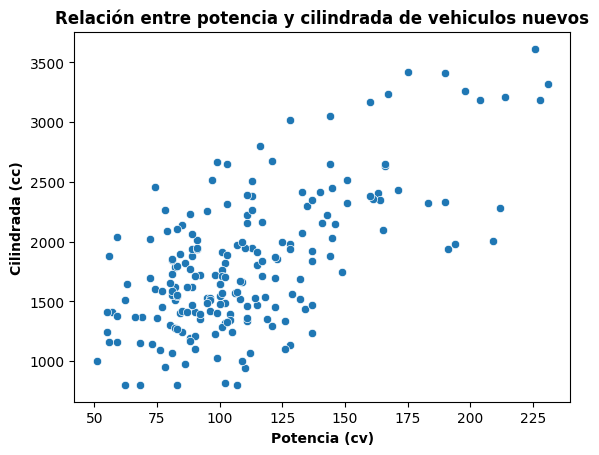

In [26]:
sns.scatterplot(data=autos,x='potencia_cv_N',y='cilindrada_cc_N')
plt.title('Relación entre potencia y cilindrada de vehiculos nuevos', fontweight='bold')
plt.xlabel('Potencia (cv)', fontweight='bold')
plt.ylabel('Cilindrada (cc)', fontweight='bold')
plt.show()

Se observa que hay una relacion positiva y moderada ya que el coeficiente de correlación de Pearson entre la cilindrada y la potencia de los autos nuevos es r=0.6550

### Ejercicio 7

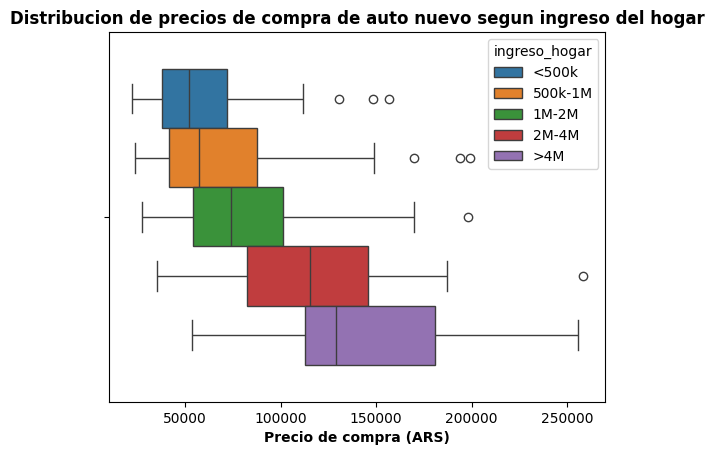

In [50]:
sns.boxplot(data=union,x='precio_compra_N',hue='ingreso_hogar',hue_order=['<500k','500k-1M','1M-2M','2M-4M','>4M'])
plt.title('Distribucion de precios de compra de auto nuevo segun ingreso del hogar', fontweight='bold')
plt.xlabel('Precio de compra (ARS)', fontweight='bold')
plt.show()


Se observa que los hogares con menos ingresos(desde <500k a 1M) compran autos mas baratos con marcadas excepciones que se aprecian en la grafica. Tambien se observa que el grupo con mejor poder adquisitivo no se limita unicamente a los autos de alta gama. El menor precio de los autos es similar para todos los diferentes ingresos.